<a href="https://colab.research.google.com/github/elianpuuig/AM2/blob/main/TP1_ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Voy a retomar el ejercicicio de regresion, pero esta vez aplicandole una solucion con redes neuronales**

## **OBJETIVO**

**Predecir el precio de unidad de area de las viviendas de taiwan osea (una variable numerica continua)**

**Como?** *Desarrollando una red neuronal de regresion desde 0 en pytorch.*
  
  *Al saber que es un problema de regresión, la estructura de la capa de salida: debe tener exactamente una sola neurona pero ninguna función de activación (para que devuelva el valor real del precio), y la *funcion* de pérdida a optimizar será el Error Cuadrático Medio (MSELoss).*

**Por que?** *El objetivo es manipular la arquitectura de la red neuronal (poner o sacar capas y neuronas) para asi forzar y graficar escenarios de subajuste(underfiting) y sobreajuste (overfiting)*

**Para ello traigo los datos y realizo su respectivo ETL**

*Es muy importante escalar los datos para que no se confunda 3000 metros al subte con 3 tiendas*


Estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


None


Estadísticas descriptivas:


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


###################################
Valores Nulos: X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64
###################################
Valores duplicados: 0


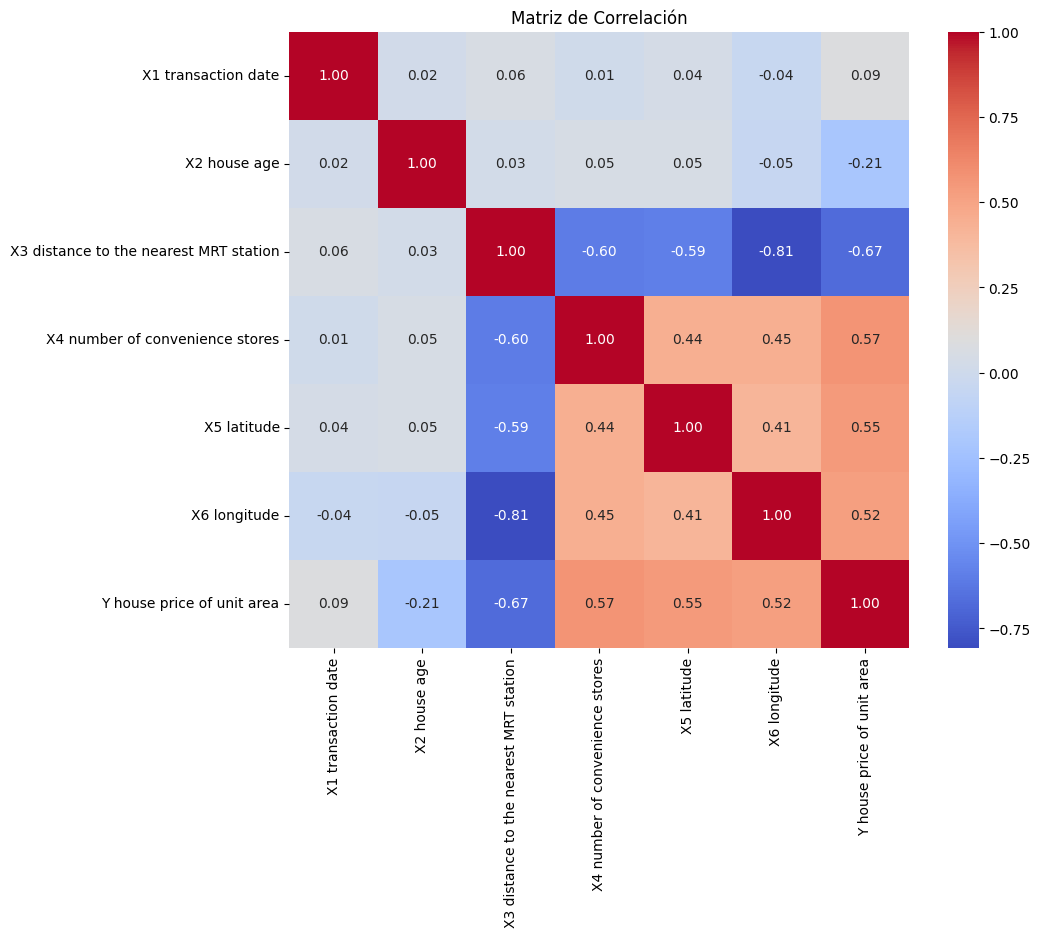

###################################


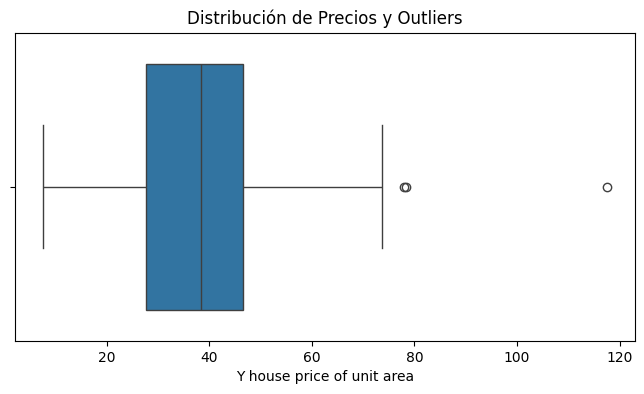

Y house price of unit area
Registros antes: 414. Registros después de limpiar outliers: 411
Contamos con un dataset con 6 variables predictoras (X) 
y 1 variable de  objetivo (Y).


In [ ]:
#Traje los datos desde mi drive
df = pd.read_excel("/content/drive/MyDrive/Real estate valuation data set.xlsx")

#´Veo como vienen los datos
print("Estructura del dataset:")
display(df.info())
print("\nEstadísticas descriptivas:")
display(df.describe())

# La columna 'No' es solamente un ID, no aporta valor predictivo y puede generar ruido, asi que la saco.
if 'No' in df.columns:
    df = df.drop('No', axis=1)

#Voy a detectar los valores faltantes y duplicados
print("#"*35)
print(f"Valores Nulos: {df.isnull().sum()}")
print("#"*35)
print(f"Valores duplicados: {df.duplicated().sum()}")


#VOy a hacer un analisis de correlacion de variables y outliers graficandolas
# Analisis de Correlaciones (Fundamental para regresión)
#Explicaicon
""" df.corr()
calcula la correlación lineal entre todas las columnas numéricas de un conjunto de datos.
Devuelve una tabla nueva (matriz) donde los valores van de -1 a 1 para mostrar
cómo se relacionan las variables entre sí.

"""
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()
print("#"*35)
# Detectando Outliers en la variable objetivo (Precio)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df.iloc[:, -1]) #Selecciono la última columna (el precio de casa por unidad de area)
plt.title("Distribución de Precios y Outliers")
plt.show()


#Al encontrar valores atipicos de casas.. voy a eliminarlos usando IQR sobre el precio de casas por unidad de area

#Para eso selecciono esa variable
precio_casa_por_unidad = df.columns[-1]
print(precio_casa_por_unidad)

#elimino los outliers de la columna usando IQR
Q1 = df[precio_casa_por_unidad].quantile(0.25)
Q3 = df[precio_casa_por_unidad].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

#Devuelvo el dataset sin outliers,
#donde el el precio sea mayor al limite inferior y menor al limite superior
dfTaiwan = df[(df[precio_casa_por_unidad] >= limite_inferior) &
              (df[precio_casa_por_unidad] <= limite_superior)]

print(f"Registros antes: {len(df)}. Registros después de limpiar outliers: {len(dfTaiwan)}")

print(f"Contamos con un dataset con {dfTaiwan.shape[1]-1} variables predictoras (X) ")
print(f"y 1 variable de  objetivo (Y).")

# **ESCALAMIENTO**

Es muy importante escalar los datos de las variables de entrada para que los pesos en la red no fallen en la repropagacion

In [ ]:
#separación de variables predictoras (X) y objetivo (y)
X = dfTaiwan.iloc[:, :-1].values

#pandas me devuelve un arreglo unidimensional
#uso reshape para que me lo devuelva bidimensional para pythorch
y = dfTaiwan.iloc[:, -1].values.reshape(-1, 1)

#Datos de prueba y entrenmiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Escalado de Datos Con standarScaler
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

#Escale el target (y) para estabilizar el entrenamiento
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Converti X e Y ambos de (train y test) Tensores de PyTorch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

print(f"Tensor X_train shape: {X_train_tensor.shape}")
print(f"Tensor y_train shape: {y_train_tensor.shape}")

Tensor X_train shape: torch.Size([328, 6])
Tensor y_train shape: torch.Size([328, 1])


#DATALOADERS


In [ ]:
# --- TensorDataset DATALOADERS ---
batch_size = 32 #divido los datos en lotes de 32 datos, para no saturar memoria

#Cree dataset de entrenamiento y prueba
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#Cree los dataloader el de entrenamiento va a mezlcar los datos para evitar que
#el modelo aprenda patrones en orden
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


#RED NEURONAL MLP INICIAL

*Elegi hacer una red neuronal estilo Perceptron Multicapa, como en el mercado inmobiliario la realidad es no lineal (ejemplo: hay mucha diferencia de precio entre una casa que esta a 100mt del mar a una de 500 pero muy poca diferencia entre una casa que esta a 5000 y otra a 5500. las capas ocultas de las redes MLP le dan la capacidad de aprender este tipo de curvas complejas*

In [ ]:

class RedInmobiliaria(nn.Module):
  def __init__(self):
    #inicializo la clase nn.Module de pytorch
    super().__init__()
    #Hiperparametros nn.Linear()

    #Le paso 6 variables de entrada (mis 6 variables predictorias)
    #devuelvo x conexiones/neuronas
    self.capa_entrada = nn.Linear(in_features=6, out_features=64)
    #hago la activacion con ReLU()
    #este apaga los negativos y deja los positivos (no linealidad)
    self.activacion1 = nn.ReLU()
    # apago el un porcentaje de nueoranas el (50%)
    # en esta capa por cada epoch,esto obliga a la red a no aprender de una
    # nuerona sino encontrar si o si patrones complejos y generalizar mejor
    self.dropout = nn.Dropout(p=0.5)

    #segunda capa
    self.capa_oculta = nn.Linear(in_features=64,out_features=32)
    #activo
    self.activacion2 = nn.ReLU()
    #vuelvo a hacer un droupout
    self.dropout2 = nn.Dropout(p=0.3)



    #salida
    #esta no lleva activación porque queremos el valor crudo (regresión)
    self.salida = nn.Linear(in_features=32,out_features=1)

  def forward(self, x):
        # El orden de ejecucion de cómo fluye la información
        x = self.capa_entrada(x)
        x = self.activacion1(x)
        x = self.dropout(x)

        x = self.capa_oculta(x)
        x = self.activacion2(x)
        x = self.dropout2(x)


        x = self.salida(x)
        return x




#RED underfiting
Le voy a dar poca informacion para que no tenga la capacidad de aprender, para ver como reacciona la red

In [ ]:
class RedInmobiliariaUnderfitting(nn.Module):
  def __init__(self):
    super().__init__()

    self.capa_entrada = nn.Linear(in_features=6,out_features=2)
    self.activacion1 = nn.ReLU()
    self.salida = nn.Linear(in_features=2,out_features=1)

  def forward(self, x):

        x = self.capa_entrada(x)
        x = self.activacion1(x)
        x = self.salida(x)
        return x


##RED overfiting
Le voy a dar mucha informacion para que la red memorice en vez de aprender, para ver como reacciona.

In [ ]:
class RedInmobiliariaOverfiting(nn.Module):
  def __init__(self):
    super().__init__()

    self.capa_entrada = nn.Linear(in_features=6,out_features=256)
    self.activacion1 = nn.ReLU()

    self.capa_oculta2 = nn.Linear(in_features=256,out_features=128)
    self.activacion2 = nn.ReLU()

    self.capa_oculta3 = nn.Linear(in_features=128,out_features=64)
    self.activacion3 = nn.ReLU()

    self.capa_oculta4 = nn.Linear(in_features=64,out_features=32)
    self.activacion4 = nn.ReLU()

    self.salida = nn.Linear(in_features=32,out_features=1)

  def forward(self, x):

        x = self.capa_entrada(x)
        x = self.activacion1(x)

        x = self.capa_oculta2(x)
        x = self.activacion2(x)

        x = self.capa_oculta3(x)
        x = self.activacion3(x)

        x = self.capa_oculta4(x)
        x = self.activacion4(x)

        x = self.salida(x)
        return x

# **Voy a hacer una funcion que sirva Como bucle de entrenamiento para mis modelos**

In [ ]:
def entrenar_modelo(modelo, train_loader, test_loader, criterio, optimizador,scheduler=None, epochs=300):
    # Listas para guardar el historial de errores
    historial_train_loss = []
    historial_test_loss = []

    for epoch in range(epochs):
        # modelo en modo entrenamiento
        modelo.train()
        loss_acumulado_train = 0

        for X_batch, y_batch in train_loader:


            # primero limpiar los gradientes del lote anterior
            optimizador.zero_grad()

            # segundo la Predicción: pasar los datos por la red
            predicciones = modelo(X_batch)

            # tercero Calculo la funcion de perdida
            loss = criterio(predicciones, y_batch)

            # cuarto Backward pass (Retropropagación): viajamos atras
            # para ver cuanto se equivoco cada neurona osea el peso de los gradientes
            loss.backward()

            # quinto Optimizacion: actualizar los pesos y sesgos del backward
            # para minimizar el error
            optimizador.step()

            loss_acumulado_train += loss.item()

        # promedio del error del epoch completo
        train_loss_promedio = loss_acumulado_train / len(train_loader)
        historial_train_loss.append(train_loss_promedio)



        #AHORA LA EVALUACION
        #para ellos ponemos el modelo en modo evaluacion
        #osea .. la red no debe aprender, solo predecir
        modelo.eval()
        loss_acumulado_test = 0

        #torch.no_grad() apaga el motor de derivadas (backward) de PyTorch para ahorrar memoria y CPU
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                predicciones = modelo(X_batch)
                loss = criterio(predicciones, y_batch)
                loss_acumulado_test += loss.item()


        test_loss_promedio = loss_acumulado_test / len(test_loader)
        historial_test_loss.append(test_loss_promedio)
        if scheduler is not None:
          #le paso el sheduler que se ejecuta una vez en cada
          #epcoa, y evalua el error
          scheduler.step(test_loss_promedio)

        # Imprimimos el progreso cada 50 epochs para no inundar la pantalla
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {train_loss_promedio:.4f} | Test Loss (MSE): {test_loss_promedio:.4f}')

    return historial_train_loss, historial_test_loss



# INSTANCIANDO LOS 3 MODELOS

In [ ]:
# Instanciamos los tres modelos
modelo_optimo = RedInmobiliaria()
modelo_underfiting = RedInmobiliariaUnderfitting()
modelo_overfitting = RedInmobiliariaOverfiting()

# Función de pérdida
criterio_perdida = nn.MSELoss()

#  EJECUCIÓN MODELO BASE
print("Iniciando entrenamiento del Modelo Optimo...")

"""Weight Decay: Penaliza los pesos muy grandes en el optimizador.
Evita que la red le dé una importancia exagerada a un solo dato
 (como un outlier que se te haya escapado)."""
#El Learning Rate (Tasa de Aprendizaje)
#es el tamaño de los pasos que da la red en cada epoch.
optimizador_base = optim.Adam(
      modelo_optimo.parameters(),
      lr=0.001,
      weight_decay=1e-4)

#Voy a crear un learning rate Dinamico, para mejorar la red
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer = optimizador_base,
    mode = 'min',    #pongo min por que quiero que el error minimice
    factor=0.5,      # Multiplica el LR por 0.5 cuando se estanca (lo reduce a la mitad)
    patience=10,     # Espera 10 epochs sin mejoras antes de actuar
    # verbose=True    # Imprime un mensaje en pantalla cuando reduce el LR
)

train_losses_base, test_losses_base = entrenar_modelo(
    modelo=modelo_optimo,
    train_loader=train_loader,
    test_loader=test_loader,
    criterio=criterio_perdida,
    optimizador=optimizador_base,
    scheduler=scheduler,
    epochs=250
)

#  EJECUCIÓN MODELO UNDERFITTING
print("\nIniciando entrenamiento del Modelo Underfitting...")
optimizador_under = optim.Adam(modelo_underfiting.parameters(), lr=0.0001)

train_losses_under, test_losses_under = entrenar_modelo(
    modelo=modelo_underfiting,
    train_loader=train_loader,
    test_loader=test_loader,
    criterio=criterio_perdida,
    optimizador=optimizador_under,
    epochs=300
)

#  EJECUCIÓN MODELO OVERFITTING
print("\nIniciando entrenamiento del Modelo Overfitting...")
optimizador_over = optim.Adam(modelo_overfitting.parameters(), lr=0.001)

train_losses_over, test_losses_over = entrenar_modelo(
    modelo=modelo_overfitting,
    train_loader=train_loader,
    test_loader=test_loader,
    criterio=criterio_perdida,
    optimizador=optimizador_over,
    epochs=300
)

Iniciando entrenamiento del Modelo Optimo...
Epoch [50/250] | Train Loss (MSE): 0.2994 | Test Loss (MSE): 0.3151
Epoch [100/250] | Train Loss (MSE): 0.2651 | Test Loss (MSE): 0.3115
Epoch [150/250] | Train Loss (MSE): 0.2667 | Test Loss (MSE): 0.3114
Epoch [200/250] | Train Loss (MSE): 0.2634 | Test Loss (MSE): 0.3115
Epoch [250/250] | Train Loss (MSE): 0.2737 | Test Loss (MSE): 0.3115

Iniciando entrenamiento del Modelo Underfitting...
Epoch [50/300] | Train Loss (MSE): 0.8723 | Test Loss (MSE): 0.7014
Epoch [100/300] | Train Loss (MSE): 0.7471 | Test Loss (MSE): 0.6411
Epoch [150/300] | Train Loss (MSE): 0.6932 | Test Loss (MSE): 0.5878
Epoch [200/300] | Train Loss (MSE): 0.5719 | Test Loss (MSE): 0.5295
Epoch [250/300] | Train Loss (MSE): 0.4854 | Test Loss (MSE): 0.4777
Epoch [300/300] | Train Loss (MSE): 0.4088 | Test Loss (MSE): 0.4466

Iniciando entrenamiento del Modelo Overfitting...
Epoch [50/300] | Train Loss (MSE): 0.0909 | Test Loss (MSE): 0.3696
Epoch [100/300] | Train Los

#Fase de Inferencia

*Voy a usar la red ya entrenada para calcular el MAE/MSE/R2 pero (desescalados) para poder verlo reflejado en dolares taiwaneses y no en valores estandarizados*

In [ ]:
modelo_optimo.eval()
with torch.no_grad():
    # Predecimos sobre el test set escalado y lo pasamos a numpy
    pred_escaladas = modelo_optimo(X_test_tensor).numpy()


#Use inverse_transform ya que como habia escalado los datos para entrenar a la red,
# al momento calcular estas metricas de error lo mejor es hacerlo
#con los datos desescalados osea en dolares taiwaneses
#para der un resultado en esa moneda
pred_reales = scaler_y.inverse_transform(pred_escaladas)
y_test_real = scaler_y.inverse_transform(y_test_tensor.numpy())

# calculo las métricas comparables con mi tp de AA1
mse_pytorch = mean_squared_error(y_test_real, pred_reales)
mae_pytorch = mean_absolute_error(y_test_real, pred_reales)
r2_pytorch = r2_score(y_test_real, pred_reales)
#multiplico por 10 mil ya que en el dataset estaba achicado precio / 10mil, lo hago para mostrar el valor real
mae_dolaresTaiwaneses = mae_pytorch * 10000
print("--- MÉTRICAS REALES RED NEURONAL (BASE) ---")
print(f"MAE: {mae_pytorch:.3f}") #error absoluto medio
print(f"MSE: {mse_pytorch:.3f}") #El Error Cuadrático Medio está en unidades
print(f"R2 : {r2_pytorch:.3f}") #porcentaje de acierto 0 a 1
print(f"#"*40)
#Y house price of unit area (es un ping)
print("Un ping equivale a 3.3 metros cuadrados en taiwan")
print("Por lo tanto nuestra red se equivoco un total en Dolares Taiwaneses por Ping de : ")
print(f"MAE en Dolares Taiwaneses: {mae_dolaresTaiwaneses:.2f} NT$") #porcentaje de acierto 0 a 1

# Un 0.59 significa que la red neuronal es capaz de explicar matemáticamente el 59.22%
#de los motivos por los que el precio de una casa sube o baja
# basándose en esas 6 variables. El 40% restante es azar.

--- MÉTRICAS REALES RED NEURONAL (BASE) ---
MAE: 4.956
MSE: 56.637
R2 : 0.592
########################################
Un ping equivale a 3.3 metros cuadrados en taiwan
Por lo tanto nuestra red se equivoco un total en Dolares Taiwaneses por Ping de : 
MAE en Dolares Taiwaneses: 49556.13 NT$


# Graficando el Error

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Creamos el panel de 3 columnas
fig = make_subplots(rows=1, cols=3, subplot_titles=(
    "Subajuste (Underfitting)<br><sup>Arquitectura estrangulada (6 -> 2 -> 1)</sup>",
    "Modelo Óptimo<br><sup>Regularizado con Dropout (6 -> 64 -> 32 -> 1)</sup>",
    "Sobreajuste (Overfitting)<br><sup>Exceso de parámetros sin regularización</sup>"
))

#Underfitting
x_under = list(range(1, len(train_losses_under) + 1))
fig.add_trace(go.Scatter(x=x_under, y=train_losses_under, mode='lines', name='Train Loss', line=dict(color='#00CC96')), row=1, col=1)
fig.add_trace(go.Scatter(x=x_under, y=test_losses_under, mode='lines', name='Test Loss', line=dict(color='#EF553B')), row=1, col=1)

#Modelo Óptim
x_base = list(range(1, len(train_losses_base) + 1))
fig.add_trace(go.Scatter(x=x_base, y=train_losses_base, mode='lines', name='Train Loss', line=dict(color='#00CC96'), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=x_base, y=test_losses_base, mode='lines', name='Test Loss', line=dict(color='#EF553B'), showlegend=False), row=1, col=2)

#Overfitting
x_over = list(range(1, len(train_losses_over) + 1))
fig.add_trace(go.Scatter(x=x_over, y=train_losses_over, mode='lines', name='Train Loss', line=dict(color='#00CC96'), showlegend=False), row=1, col=3)
fig.add_trace(go.Scatter(x=x_over, y=test_losses_over, mode='lines', name='Test Loss', line=dict(color='#EF553B'), showlegend=False), row=1, col=3)


fig.update_layout(
    title_text="Análisis Comparativo de Zonas de Ajuste (MSE Loss)",
    template="plotly_dark",
    height=500,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(title_text="MSE Loss (Estandarizado)", row=1, col=1)
fig.update_xaxes(title_text="Epochs")

fig.show()

# Predicciones vs Realidad

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import torch

# predicciones reales del modelo base
modelo_optimo.eval()
with torch.no_grad():
    pred_escaladas = modelo_optimo(X_test_tensor).numpy()

# Invierto  el escalado para tener los valores en la moneda real
pred_reales = scaler_y.inverse_transform(pred_escaladas).flatten()
precio_real = scaler_y.inverse_transform(y_test_tensor.numpy()).flatten()
X_test_real = scaler_X.inverse_transform(X_test_scaled)

#
df_resultados = pd.DataFrame({
    'Edad de la Casa': X_test_real[:, 1],
    'Distancia al Tren': X_test_real[:, 2],
    'Precio Real': precio_real,
    'Precio Predicho': pred_reales
})


df_resultados['Error Absoluto'] = abs(df_resultados['Precio Real'] - df_resultados['Precio Predicho'])

fig_2d = go.Figure()


fig_2d.add_trace(go.Scatter(
    x=df_resultados['Precio Real'],
    y=df_resultados['Precio Predicho'],
    mode='markers',
    marker=dict(
        size=9,
        color=df_resultados['Error Absoluto'],
        colorscale='Turbo',
        showscale=True,
        colorbar=dict(title="Error Absoluto"),
        line=dict(width=1, color='#121212')
    ),
    text=df_resultados.apply(lambda row: f"Edad: {row['Edad de la Casa']:.1f} años<br>Dist MRT: {row['Distancia al Tren']:.1f} m", axis=1),
    hovertemplate="<b>Precio Real:</b> %{x:.1f}<br><b>Predicho:</b> %{y:.1f}<br>%{text}<extra></extra>",
    name='Casas (Test Set)'
))

min_val = min(df_resultados['Precio Real'].min(), df_resultados['Precio Predicho'].min())
max_val = max(df_resultados['Precio Real'].max(), df_resultados['Precio Predicho'].max())

fig_2d.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    line=dict(color='white', width=2, dash='dash'),
    name='Predicción Ideal'
))

fig_2d.update_layout(
    title="Desempeño del Modelo Óptimo: Precio Real vs. Precio Predicho",
    xaxis_title="Precio REAL de la Casa",
    yaxis_title="Precio PREDICHO por la Red",
    template="plotly_dark",
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig_2d.show()

*En este gráfico comparamos el precio real de cada casa contra lo que calculó la red. La línea blanca punteada es el escenario ideal. Si mi red fuera perfecta, todos los puntos estarían clavados sobre esa línea. Como vemos, la mayoría de los puntos se agrupan siguiendo la línea, lo que demuestra que la red aprendió la tendencia. Los puntos que están por encima de la línea son casas que la red sobrevaloró (predijo de más), y los que están por debajo son casas que infravaloró (predijo de menos).*